## Mutrig config optimizations for June 2026 beamtime
For this beamtime only 5 scintillators are used, in an AC-coupled configuration.
Therefore, the tuning is done by hand and few other parameters are checked and optimized to get the best readout rate with this type of readout.

In [1]:
#Modified by Maxime during the May 2026 beamtime of AMS
import json
import matplotlib.pyplot as plt
import numpy as np

def plot_threshold_scan(data, filenames, ch, ref=-1, xmin=0, xmax=256):
    """
    Read threshold_Scan15122025.json and plot rates[ch] vs th[ch]
    
    Args:
        data: dictionary containing 'th' and 'rates' keys with lists of lists
        filenames: list of filenames corresponding to the data
        ch: integer or list of integers representing channel numbers
    """    
    # Convert single channel to list for uniform handling
    channels = [ch] if isinstance(ch, int) else ch
    # Convert data to array to handle list of datasets
    data = [data] if isinstance(data, dict) else data
    
    plt.figure(figsize=(16, 6))
    plt.rcParams.update({'font.size': 18})

    for dataset in data:
        for channel in channels:
            plt.plot(dataset['th'][channel], dataset['rates'][channel],  label=f'{filenames[data.index(dataset)]} - Channel {channel}')
    
    plt.xlabel('Threshold (th)')
    plt.ylabel('Rates')
    plt.legend()
    
    #plt.vlines(ref, 0, 10**6, color='k')
    plt.xticks(np.arange(0, 256, 5), rotation=45)
    #plt.xlim(120, 191)
    plt.xlim(xmin, xmax)
    plt.yscale('log')
    plt.grid(True)
    plt.show()

# Example usage:
# plot_threshold_scan(0, [data], ['Some detector config'])  # single channel
# plot_threshold_scan([0, 1, 2], [data0, data1], ['Some detector config', 'Another detector config'])  # multiple channels

# Quick T-Threshold scan to get an idea about the noise levels
SiPMs biased at 150 (M) / 145 (others).
ISGbias = 4 

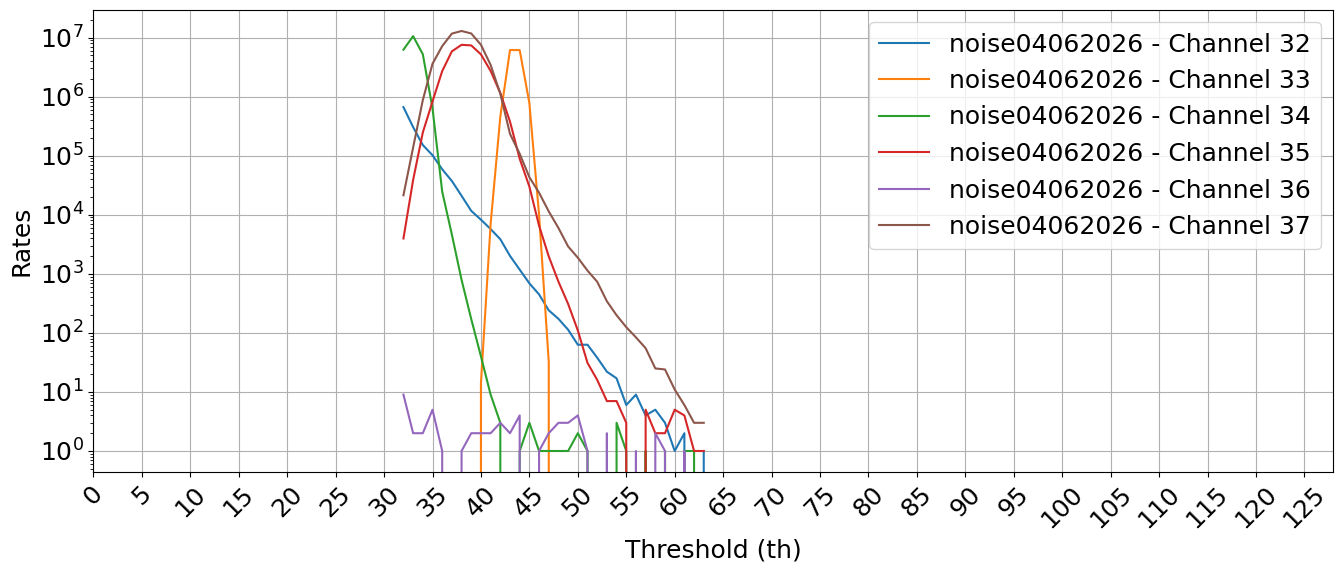

In [5]:
channelsA = [32,33,34,35,36,37]
data = json.load(open('../data/tthreshold_scan-noise04062026.json'))
plot_threshold_scan(data, ['noise04062026'], channelsA, -1, 0,128)

## Scan of TThreshold for different ISGbias.
ISGbias = 8 is chosen as it gives the best spread of the usable threshold range.

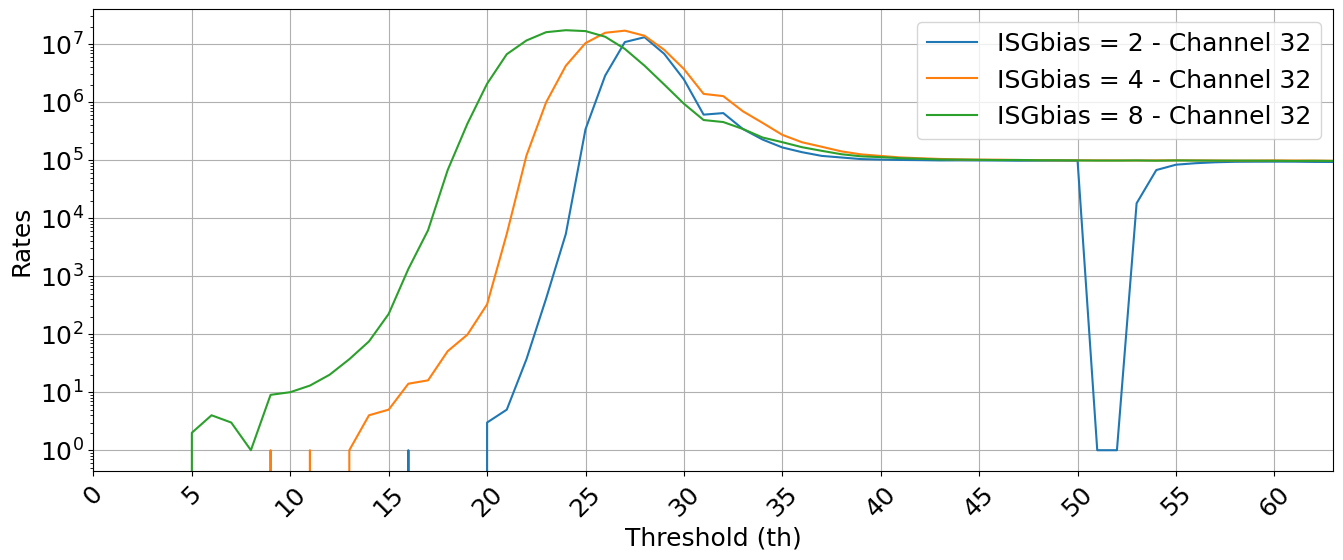

In [6]:
channels = [32]
f = [
    open('../data/tthreshold_scan-beam04062026-isgbias2.json', 'r'),
    open('../data/tthreshold_scan-beam04062026-isgbias4.json', 'r'),
    open('../data/tthreshold_scan-beam04062026-isgbias8.json', 'r'),
    ]
data = [json.load(file) for file in f]
names = ["ISGbias = 2", "ISGbias = 4", "ISGbias = 8"]
plot_threshold_scan(data, names, channels, -1, 0,63)

## T-Threshold selection with beam.
Also very close to the settings found in dark mode and at ISGbias=4:
We define two sets: a low noise configuation setting the threshold just at the onset of the noise peak,
one with noticable increase of the noise such that the noise will might also be observable in the E-threshold scan.
TTH_LN = 40,63,37,52,19,58
TTH_HN = 30,63,32,47,17,50

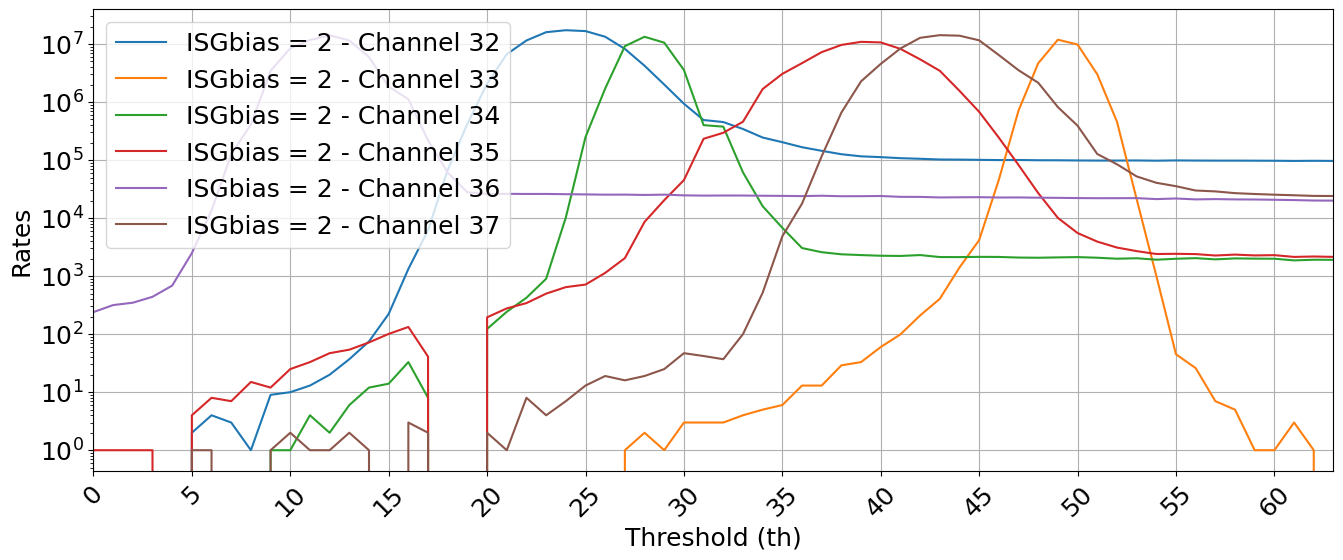

In [8]:

f = [
    open('../data/tthreshold_scan-beam04062026-isgbias8.json', 'r'),
    ]
data = [json.load(file) for file in f]
names = ["ISGbias = 2", "ISGbias = 4", "ISGbias = 8"]
plot_threshold_scan(data, names, channelsA, -1, 0,63)

# E-Threshold optimization

First for Edge=0 (Edge_cml=0)
This setting is discarded as it shows a rate behaviour very sensitive to the threshold

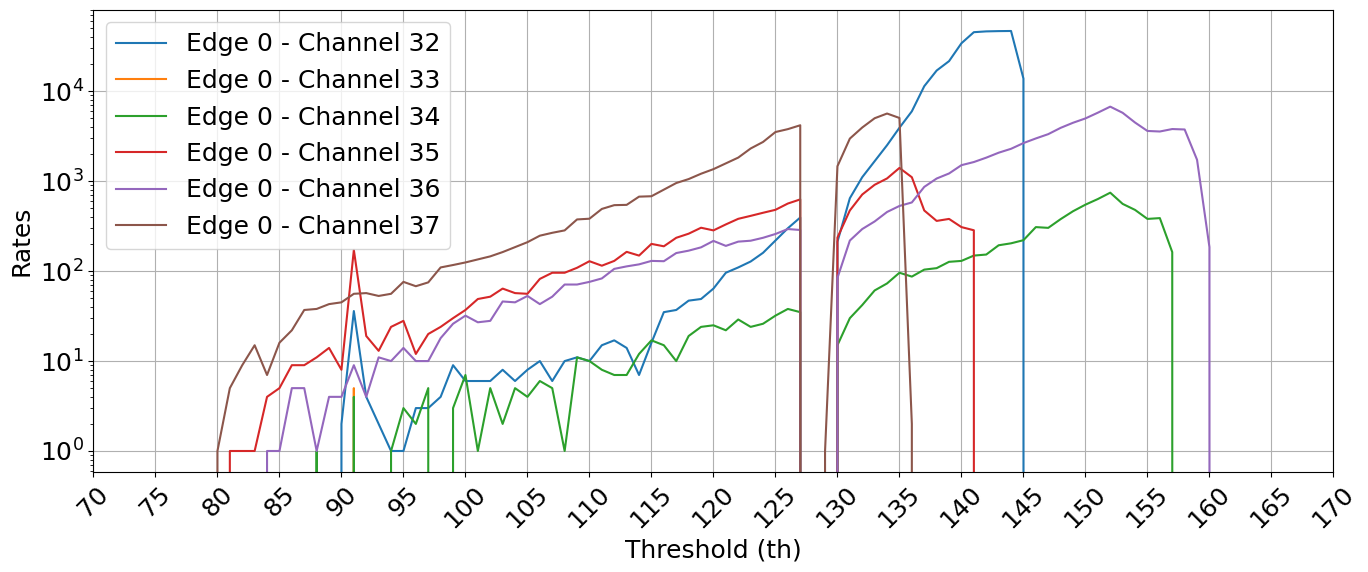

In [ ]:
with open('../data/ethreshold_scan-beam04062026_edge0.json', 'r') as f:
    data = json.load(f)
    plot_threshold_scan(data, ["Edge 0"], channelsA, -1, 70,170)

### E-Threshold optimization for Edge=1
Different R/C/Ebias/Delay configurations were tested.
Selected Delay=1: slightly higher rates same stability
Selected R=0: better insensitivity
Selected C=0: Slightly wider plateau, nice noise peak

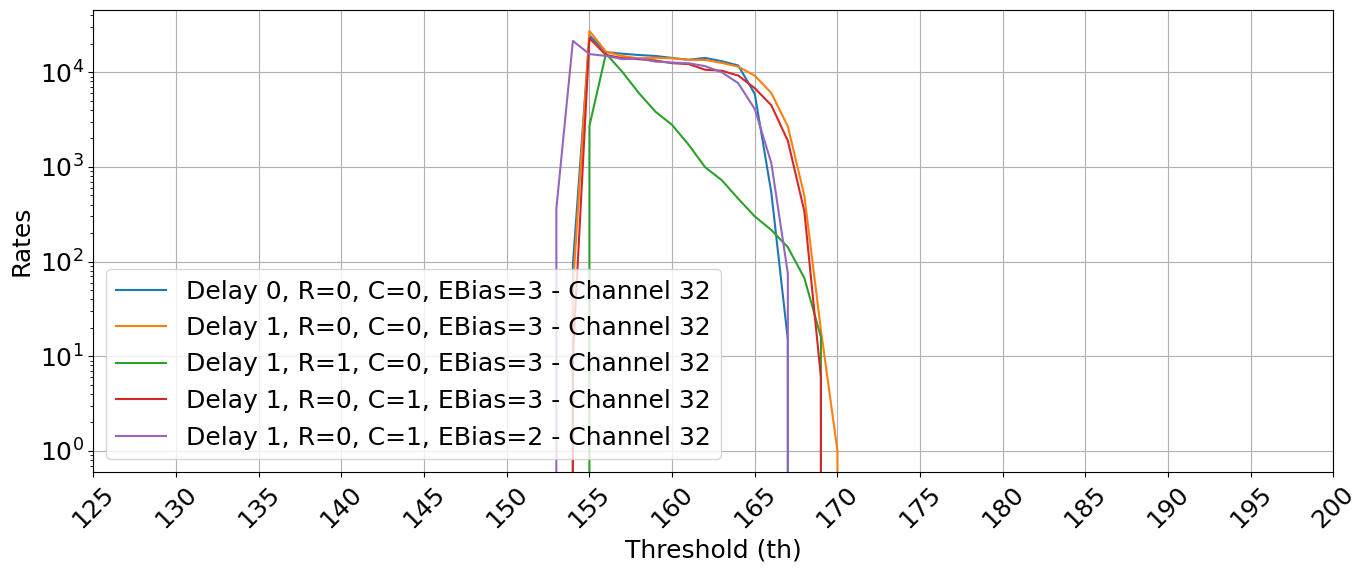

In [ ]:
channels = [32]
f = [
    open('../data/ethreshold_scan-beam04062026_edge1-delay0.json', 'r'),
    open('../data/ethreshold_scan-beam04062026_edge1-delay1.json', 'r'),
    open('../data/ethreshold_scan-beam04062026_edge1-delay1-r1.json', 'r'),
    open('../data/ethreshold_scan-beam04062026_edge1-delay1-r0-c1.json', 'r'),
    open('../data/ethreshold_scan-beam04062026_edge1-delay1-r0-c0-ebias2.json', 'r'),
    ]
data = [json.load(file) for file in f]
names = ["Delay 0, R=0, C=0, EBias=3", "Delay 1, R=0, C=0, EBias=3", "Delay 1, R=1, C=0, EBias=3", "Delay 1, R=0, C=1, EBias=3", "Delay 1, R=0, C=1, EBias=2"]
plot_threshold_scan(data, names, channels, -1, 125,200)

### Optimizations of thresholds - Low noise TTH config
Edge=1 Edge_CML=0 Delay=1 R=0 C=0 EBias=3
Selected thresholds: 156 255 163 158 150 150

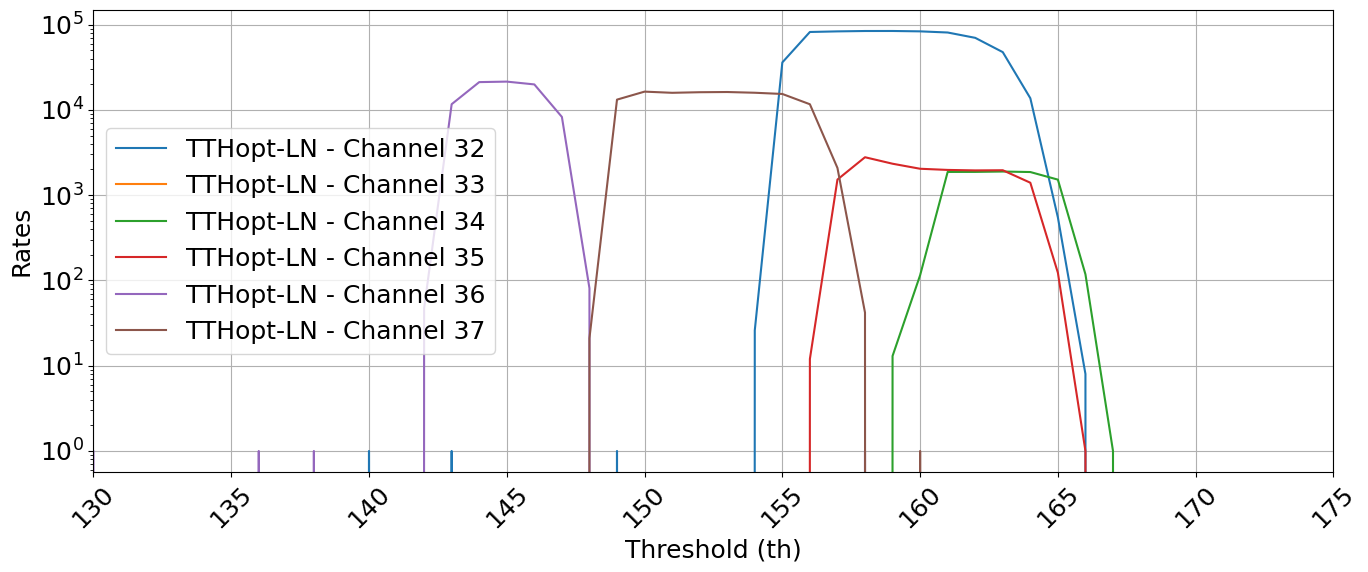

In [ ]:
f = [
    open('../data/ethreshold_scan-beam04062026-TThOPT-LN.json', 'r'),
    ]
data = [json.load(file) for file in f]
names = ["TTHopt-LN"]
plot_threshold_scan(data, names, channelsA, -1, 130,175)

### Optimizations of thresholds - High noise TTH config
Edge=1 Edge_CML=0 Delay=1 R=0 C=0 EBias=3
Selected thresholds: 156 255 159 159 143 153
But very narrow in the peaks, not a very convincing setup

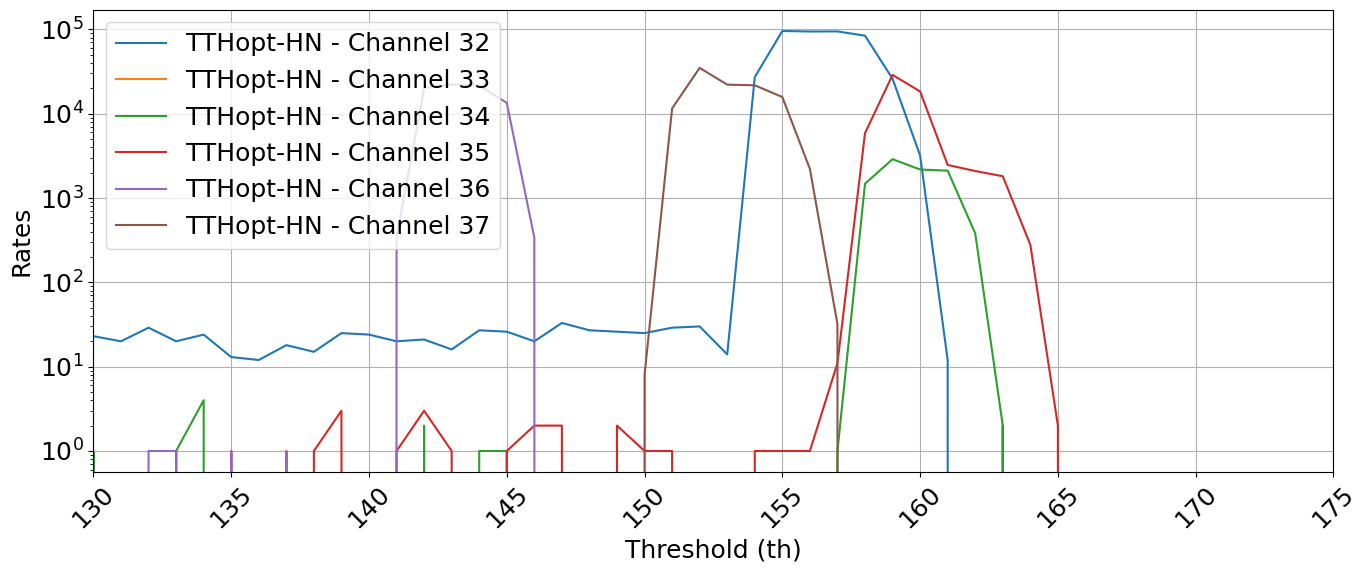

In [20]:
f = [
    open('../data/ethreshold_scan-beam04062026-TThOPT-HN.json', 'r'),
    ]
data = [json.load(file) for file in f]
names = ["TTHopt-HN"]
plot_threshold_scan(data, names, channelsA, -1, 130,175)

### Optimizations of thresholds - High noise TTH config (EDGE_CML=1)
Edge-CML should be 1 for this config. This makes the usable settings much wider
and the rates are almost perfect
Selected thresholds: 156 255 162 162 144 154


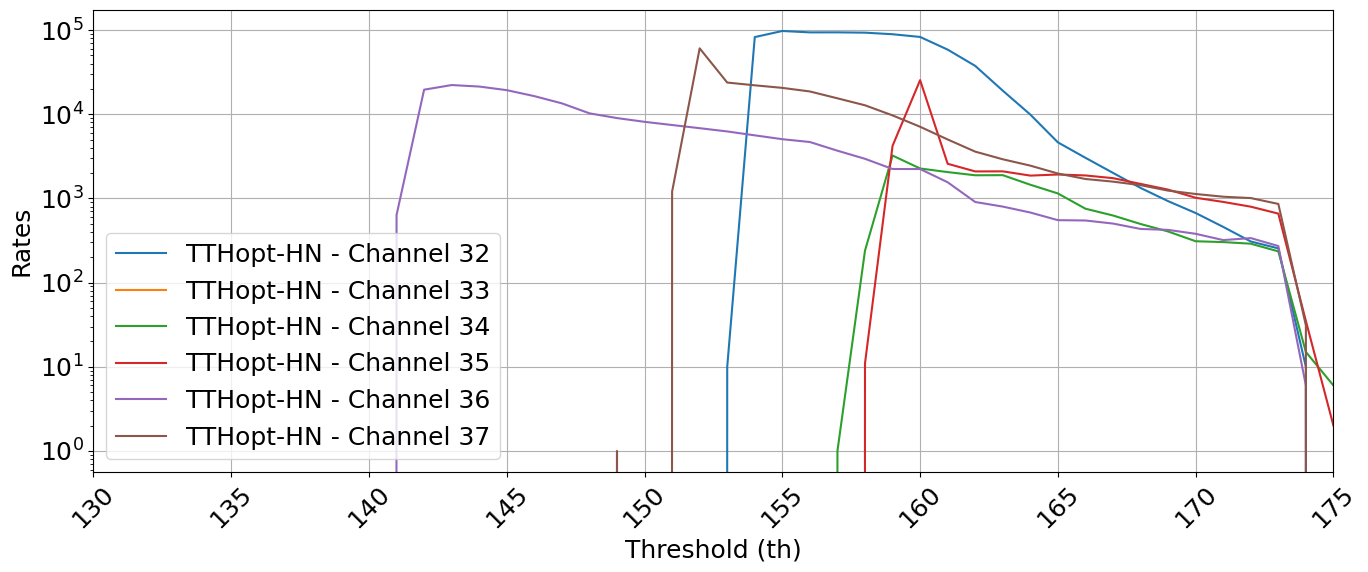

In [21]:
f = [
    open('../data/ethreshold_scan-beam04062026-TThOPT-HN-edge1-edgecml1.json', 'r'),
    ]
data = [json.load(file) for file in f]
names = ["TTHopt-HN"]
plot_threshold_scan(data, names, channelsA, -1, 130,175)